# DLPFC 10x Visium multi-section benchmark

This notebook evaluates STEP on 12 human dorsolateral prefrontal cortex (DLPFC) sections organized into three four-section groups. Each group is jointly represented and clustered, and the inferred spatial domains are compared with the manually annotated cortical layers using the adjusted Rand index (ARI). The workflow also exports domain assignments and visualizes domain-associated genes.

| Group | Sections |
|:--|:--|
| P1 | 151507, 151508, 151509, 151510 |
| P2 | 151669, 151670, 151671, 151672 |
| P3 | 151673, 151674, 151675, 151676 |

The notebook expects the annotated section-level AnnData objects under `./data/<section>/<section>_annotated.h5ad` and writes generated artifacts under `./results/DLPFC/`.

**Data source:** Twelve human DLPFC Space Ranger outputs from the [spatialLIBD HumanPilot repository](https://github.com/LieberInstitute/HumanPilot).

In [ ]:
import os
from pathlib import Path

import anndata as ad
import scanpy as sc
from sklearn.metrics import adjusted_rand_score

from step import stModel

results_dir = Path("./results/DLPFC")
results_dir.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(results_dir)
sc.set_figure_params(dpi_save=300, figsize=(6, 4.5))

## P3: sections 151673-151676

The four P3 sections are concatenated with section identity retained as the batch label. STEP learns a joint spatial representation, clusters the smoothed embedding, and evaluates each section against its cortical-layer annotation.


In [2]:
paths = [f'./data/{i}/{i}_annotated.h5ad' for i in range(151673, 151677)]
import os
import anndata as ad

adatas = [sc.read_h5ad(path) for path in paths]
adatas = {f'{151673 + i}': adata for i, adata in enumerate(adatas)}
adata = ad.concat(adatas, uns_merge='unique', label='batch')

In [6]:
client = stModel(
    adata=adata,
    n_top_genes=2000,
    layer_key=None,
    batch_key='batch',
    module_dim=30,
    hidden_dim=64,
    n_modules=10,
    decoder_type='zinb',
    use_earlystop=False,
    variational=True,
    n_glayers=6,
)

not log_transformed
Adding count data to layer 'counts'
Dataset Done
Modeling with 1 components


In [7]:
client.run(epochs=800, 
           batch_size=1024, 
           split_rate=0.,
           gsplit_rate=0.,
           graph_batch_size=2, 
           n_iterations=2000,
           kl_cutoff=None,
           beta=1e-2)
adata = client.adata

Training with e2e pattern
Training graph with multiple batches


100%|██████████| 2000/2000 [04:03<00:00,  8.22step/s, recon_loss=896.131, kl_loss=0.494, contrast_loss=0.450, val_recon_loss=-, val_kl_loss=-, val_contrast_loss=-] 


In [8]:
client.cluster(adata, use_rep='X_smoothed', n_clusters=7, key_added='cluster_',)
sc.pp.neighbors(adata, use_rep="X_smoothed", n_neighbors=60)
sc.tl.umap(adata)

In [12]:
from sklearn.metrics import adjusted_rand_score

adata = adata[adata.obs['gd'] != 'NA']
for i in range(151673, 151677):
    _adata = adata[adata.obs['batch'] == str(i)]
    ari_kmeans = adjusted_rand_score(_adata.obs['cluster_'], _adata.obs['gd'].cat.codes)
    print(f"{i}: {ari_kmeans}")

151673: 0.6754080012934679
151674: 0.6724074253563272
151675: 0.6269232035244521
151676: 0.6320154728412017


In [13]:
adata.write_h5ad("./results/DLPFC/151673_to_151676_integrated.h5ad")

### P3 spatial domains and exports

Reload the fitted object, export the domain assignments, and generate joint UMAP and section-level spatial views. Each spatial title reports the section-specific ARI.


In [13]:
adata = sc.read_h5ad("./results/DLPFC/151673_to_151676_integrated.h5ad")

In [3]:
adata.obs[['batch', 'cluster_']].to_csv("./results/DLPFC/p3_res.csv")

In [3]:
for col in ['cluster_', 'batch']:
    sc.pl.umap(adata, color=col, show=False, save=f"_151673_to_151676_{col}.png")

In [3]:
for i in range(151673, 151677):
    _adata = adata[adata.obs['batch'] == str(i)]
    ari_kmeans = adjusted_rand_score(_adata.obs['cluster_'], _adata.obs['gd'].cat.codes)
    sc.pl.spatial(_adata, color='cluster_', library_id=str(i), 
                  title=f'{i}_ari_{ari_kmeans: .2f}',
                  show=False,
                  save=f'_{i}_integrated.png',
                 )

### P3 domain-associated genes

Rank genes across inferred domains and visualize the strongest domain-associated expression programs in each section.


In [14]:
adata.uns['log1p']['base'] = None
adata.obs['domain'] = adata.obs['cluster_'].astype(str).astype('category')
sc.tl.dendrogram(adata, use_rep='X_smoothed', groupby='domain')
sc.tl.rank_genes_groups(adata, groupby='domain', use_raw=True,)

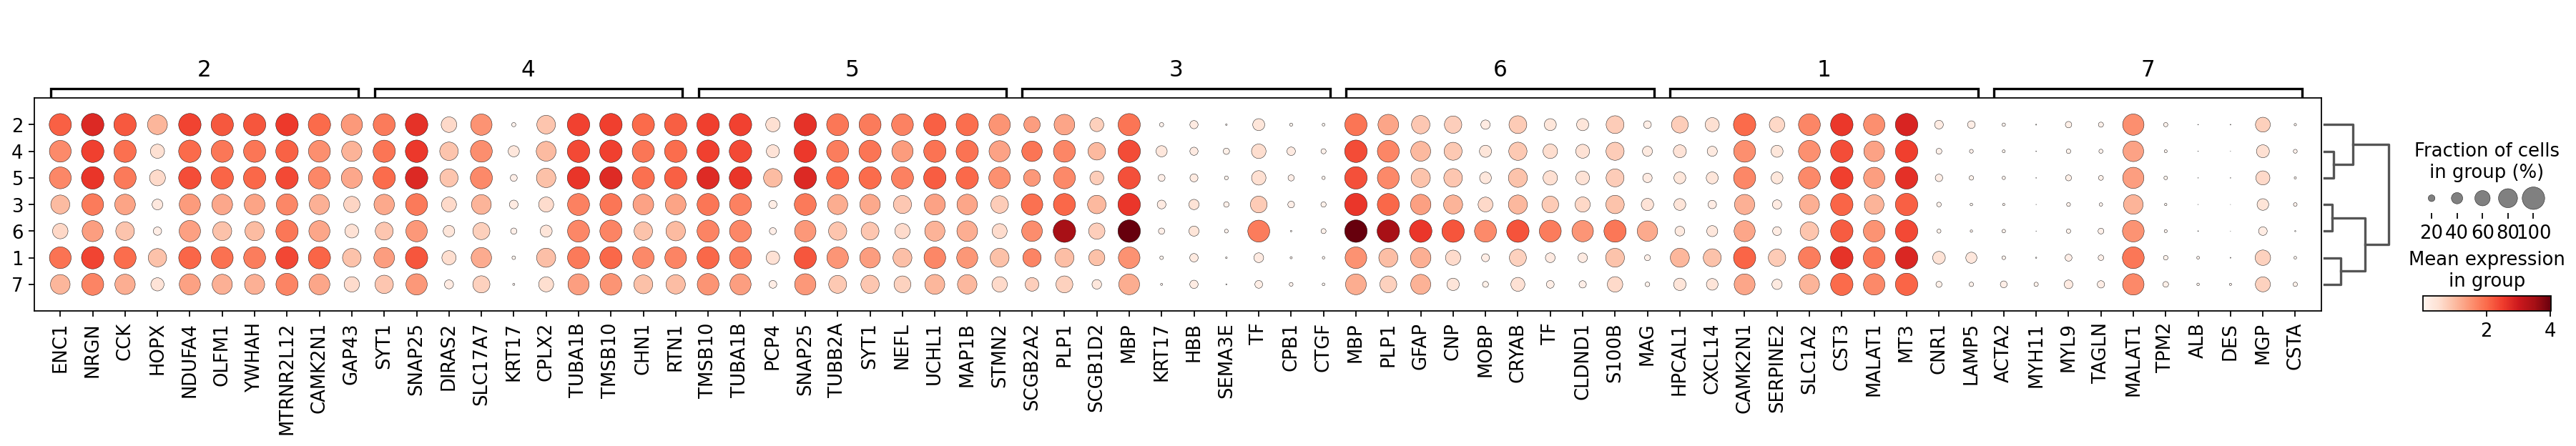

In [4]:
sc.pl.rank_genes_groups_dotplot(adata, groupby='domain', use_raw=True)

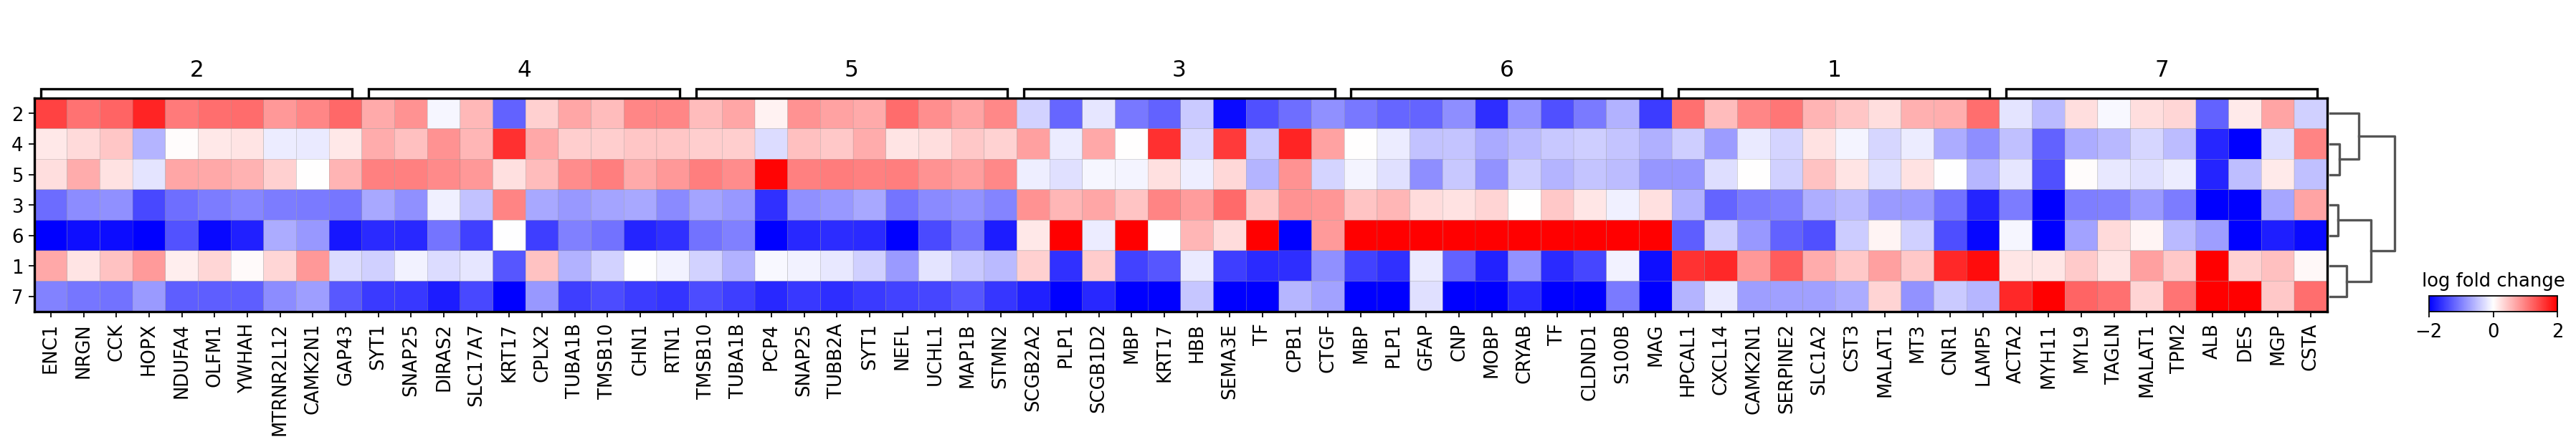

In [14]:
sc.pl.rank_genes_groups_matrixplot(adata, groupby='domain', use_raw=True, values_to_plot='logfoldchanges', vmin=-2, vmax=2, cmap='bwr')

In [15]:
results = adata.uns['rank_genes_groups']
groups = results['names'].dtype.names
figdir = f"./results/DLPFC/degenes/p3/"
if not os.path.exists(figdir):
    os.makedirs(figdir)
sc.settings.figdir = figdir
for group in groups:
    genes = results["names"][group][:5]
    print(f'Domain {group}, top {len(genes)} significant genes: {genes}')
    for i in range(151673, 151677):
        _adata = adata[adata.obs['batch'] == str(i)]
        for gene in genes:
            sc.pl.spatial(_adata, color=gene, img_key=None, library_id=str(i), size=1.3, cmap='Blues', show=False, save=f"_p3_{i}_{group}_{gene}.png")

Domain 1, top 5 significant genes: ['HPCAL1' 'CXCL14' 'CAMK2N1' 'SERPINE2' 'SLC1A2']
Domain 2, top 5 significant genes: ['ENC1' 'NRGN' 'CCK' 'HOPX' 'NDUFA4']
Domain 3, top 5 significant genes: ['SCGB2A2' 'PLP1' 'SCGB1D2' 'MBP' 'KRT17']
Domain 4, top 5 significant genes: ['SYT1' 'SNAP25' 'DIRAS2' 'SLC17A7' 'KRT17']
Domain 5, top 5 significant genes: ['TMSB10' 'TUBA1B' 'PCP4' 'SNAP25' 'TUBB2A']
Domain 6, top 5 significant genes: ['MBP' 'PLP1' 'GFAP' 'CNP' 'MOBP']
Domain 7, top 5 significant genes: ['ACTA2' 'MYH11' 'MYL9' 'TAGLN' 'MALAT1']


## P2: sections 151669-151672

The P2 sections are processed jointly using the same representation, spatial-domain evaluation, and marker-analysis workflow.


In [14]:
paths = [f'./data/{i}/{i}_annotated.h5ad' for i in range(151669, 151673)]
import os
import anndata as ad

adatas = [sc.read_h5ad(path) for path in paths]
adatas = {f'{151669 + i}': adata for i, adata in enumerate(adatas)}
adata = ad.concat(adatas, uns_merge='unique', label='batch')

In [18]:
client = stModel(
    adata=adata,
    n_top_genes=2000,
    layer_key=None,
    batch_key='batch',
    module_dim=30,
    hidden_dim=64,
    n_modules=10,
    decoder_type='zinb',
    use_earlystop=False,
    variational=True,
    edge_clip=4,
    n_glayers=6,
)

not log_transformed
Adding count data to layer 'counts'
Dataset Done
Modeling with 1 components


In [19]:
client.run(epochs=800, 
           batch_size=1024, 
           split_rate=0.,
           graph_batch_size=1, 
           n_iterations=2000,
           kl_cutoff=None,
           beta=1e-3)
adata = client.adata

Training with e2e pattern
Training graph with multiple batches


100%|██████████| 2000/2000 [02:19<00:00, 14.33step/s, recon_loss=702.078, kl_loss=0.102, contrast_loss=0.008, val_recon_loss=-, val_kl_loss=-, val_contrast_loss=-]


In [20]:
client.cluster(adata, use_rep='X_smoothed', n_clusters=5, key_added='cluster_',)
sc.pp.neighbors(adata, use_rep="X_smoothed", n_neighbors=60)
sc.tl.umap(adata)

In [26]:
from sklearn.metrics import adjusted_rand_score

adata = adata[adata.obs['gd'].cat.codes != -1]
for i in range(151669, 151673):
    _adata = adata[adata.obs['batch'] == str(i)]
    ari_kmeans = adjusted_rand_score(_adata.obs['cluster_'], _adata.obs['gd'].cat.codes)
    print(f"{i}: {ari_kmeans}")

151669: 0.473063133756929
151670: 0.4823243487550628
151671: 0.6081826774556868
151672: 0.6510144244034336


In [25]:
adata.write_h5ad("./results/DLPFC/151669_to_151672_integrated.h5ad")

### P2 spatial domains and exports

Reload the fitted object, export domain assignments, and generate section-level spatial and joint UMAP views.


In [10]:
adata = sc.read_h5ad("./results/DLPFC/151669_to_151672_integrated.h5ad")

In [5]:
adata.obs[['batch', 'cluster_']].to_csv("./results/DLPFC/p2_res.csv")

In [2]:
for i in range(151669, 151673):
    _adata = adata[adata.obs['batch'] == str(i)]
    ari_kmeans = adjusted_rand_score(_adata.obs['cluster_'], _adata.obs['gd'].cat.codes)
    sc.pl.spatial(_adata, color='cluster_', library_id=str(i), 
                  title=f'{i}_ari_{ari_kmeans: .2f}',
                  save=f'_{i}_integrated.png',
                  show=False,
                 )

In [4]:
for col in ['cluster_', 'batch']:
    sc.pl.umap(adata, color=col, 
               save=f'_151669_to_151672_integrated_{col}.png',
               show=False,)

### P2 domain-associated genes

Rank genes across inferred domains and visualize their spatial expression across the four sections.


In [11]:
adata.uns['log1p']['base'] = None
adata.obs['domain'] = adata.obs['cluster_'].astype(str).astype('category')
sc.tl.dendrogram(adata, use_rep='X_smoothed', groupby='domain')
sc.tl.rank_genes_groups(adata, groupby='domain', use_raw=True, method='wilcoxon')

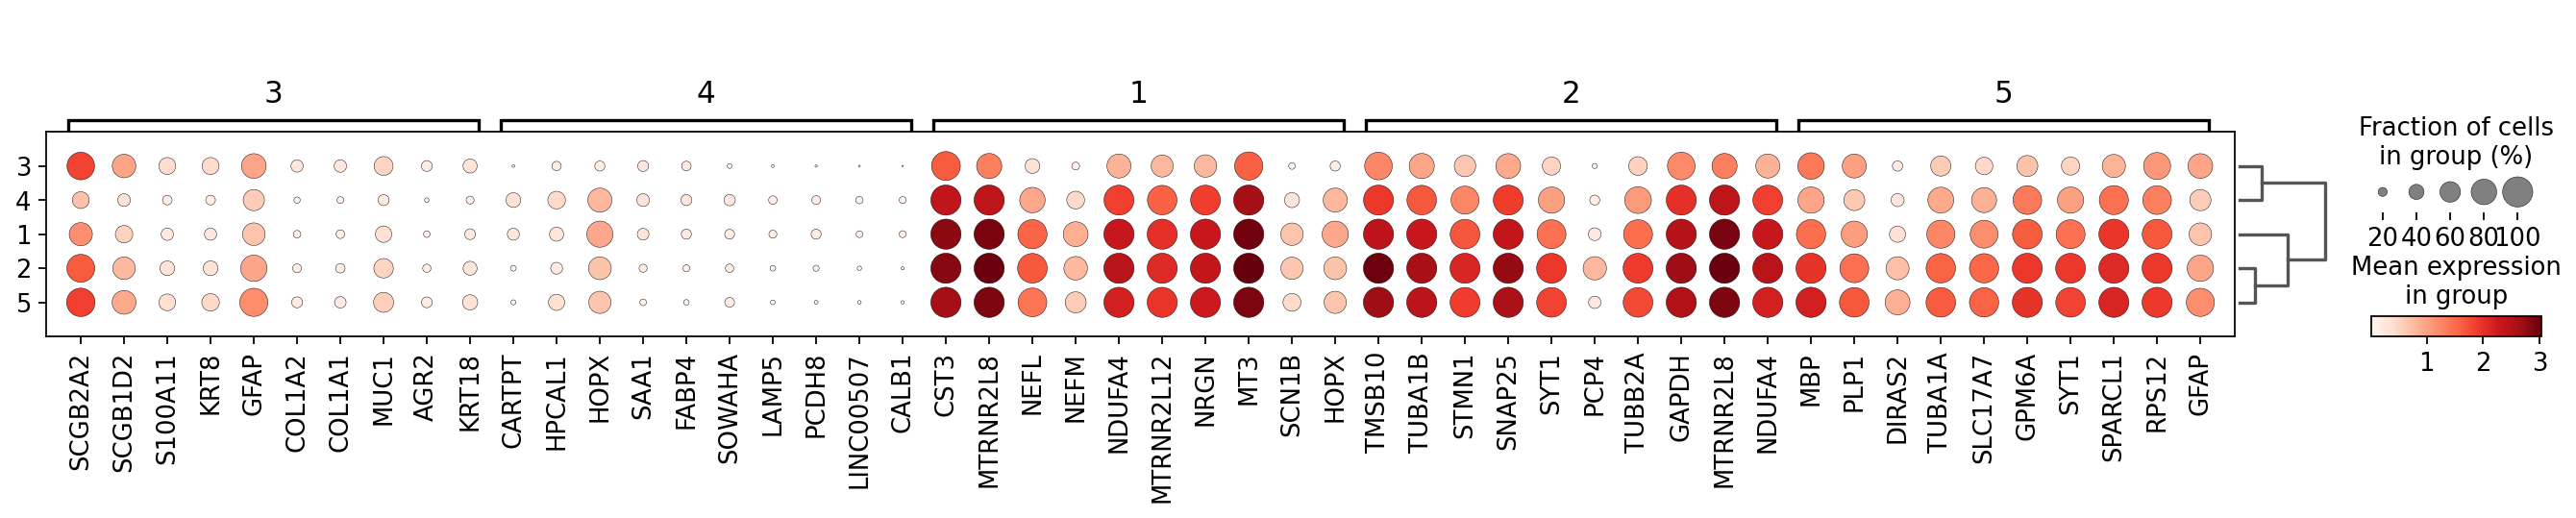

In [6]:
sc.pl.rank_genes_groups_dotplot(adata, groupby='domain', use_raw=True)

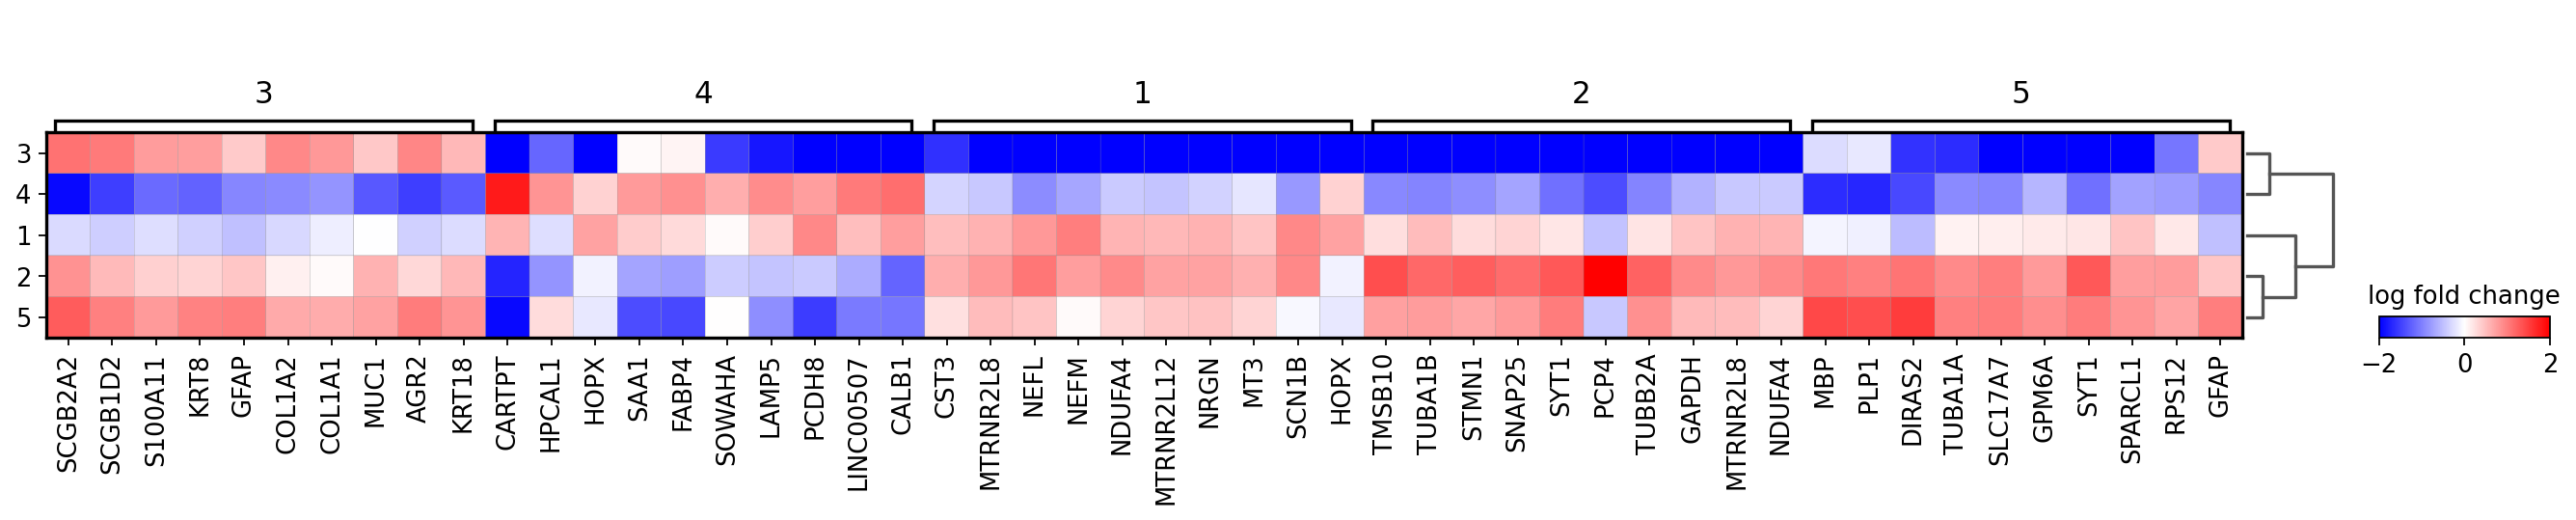

In [9]:
sc.pl.rank_genes_groups_matrixplot(adata, groupby='domain', use_raw=True, values_to_plot='logfoldchanges', vmin=-2, vmax=2, cmap='bwr')

In [12]:
results = adata.uns['rank_genes_groups']
groups = results['names'].dtype.names
figdir = f"./results/DLPFC/degenes/p2/"
if not os.path.exists(figdir):
    os.makedirs(figdir)
sc.settings.figdir = figdir
for group in groups:
    genes = results["names"][group][:5]
    print(f'Domain {group}, top {len(genes)} significant genes: {genes}')
    for i in range(151669, 151673):
        _adata = adata[adata.obs['batch'] == str(i)]
        for gene in genes:
            sc.pl.spatial(_adata, 
                          color=gene, 
                          img_key=None, 
                          library_id=str(i), 
                          size=1.3, 
                          cmap='Blues', 
                          show=False, 
                          save=f"_p2_{i}_{group}_{gene}.png"
                         )

Domain 1, top 5 significant genes: ['CST3' 'MTRNR2L8' 'NEFL' 'NEFM' 'NDUFA4']
Domain 2, top 5 significant genes: ['TMSB10' 'TUBA1B' 'STMN1' 'SNAP25' 'SYT1']
Domain 3, top 5 significant genes: ['SCGB2A2' 'SCGB1D2' 'S100A11' 'KRT8' 'GFAP']
Domain 4, top 5 significant genes: ['CARTPT' 'HPCAL1' 'HOPX' 'SAA1' 'FABP4']
Domain 5, top 5 significant genes: ['MBP' 'PLP1' 'DIRAS2' 'TUBA1A' 'SLC17A7']


## P1: sections 151507-151510

Load the fitted P1 object, generate joint embedding views, export its domain assignments, and identify domain-associated genes.


In [2]:
adata = sc.read_h5ad("./results/DLPFC/151507_to_151510_integrated.h5ad")

In [4]:
adata.uns.pop('domain_colors', None)
sc.set_figure_params(dpi_save=300, figsize=(6, 4.5))
sc.pp.neighbors(adata, use_rep='X_smoothed', n_neighbors=120)
sc.tl.umap(adata)
sc.pl.umap(adata, color='domain', save="151507_to_151510_domain.png", show=False)
sc.pl.umap(adata, color='batch', save="151507_to_151510_batch.png", show=False)

<AxesSubplot:title={'center':'batch'}, xlabel='UMAP1', ylabel='UMAP2'>

In [7]:
adata.obs[['batch', 'domain']].to_csv("./results/DLPFC/p1_res.csv")

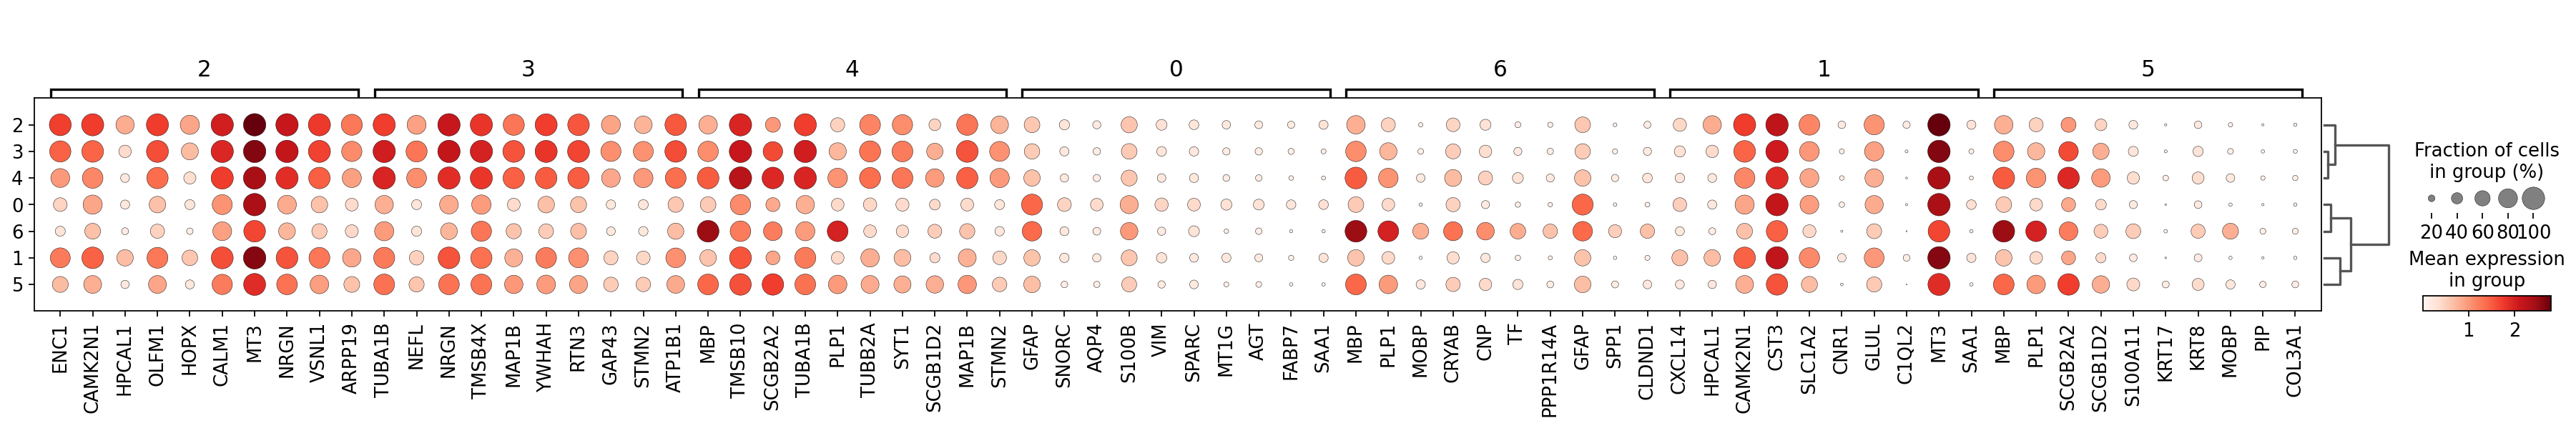

In [4]:
adata.uns['log1p']['base'] = None
adata.obs['domain'] = adata.obs['domain'].cat.codes.astype(str).astype('category')
sc.tl.dendrogram(adata, use_rep='X_smoothed', groupby='domain')
sc.tl.rank_genes_groups(adata, groupby='domain', use_raw=True, method='wilcoxon')

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, groupby='domain', use_raw=True,)

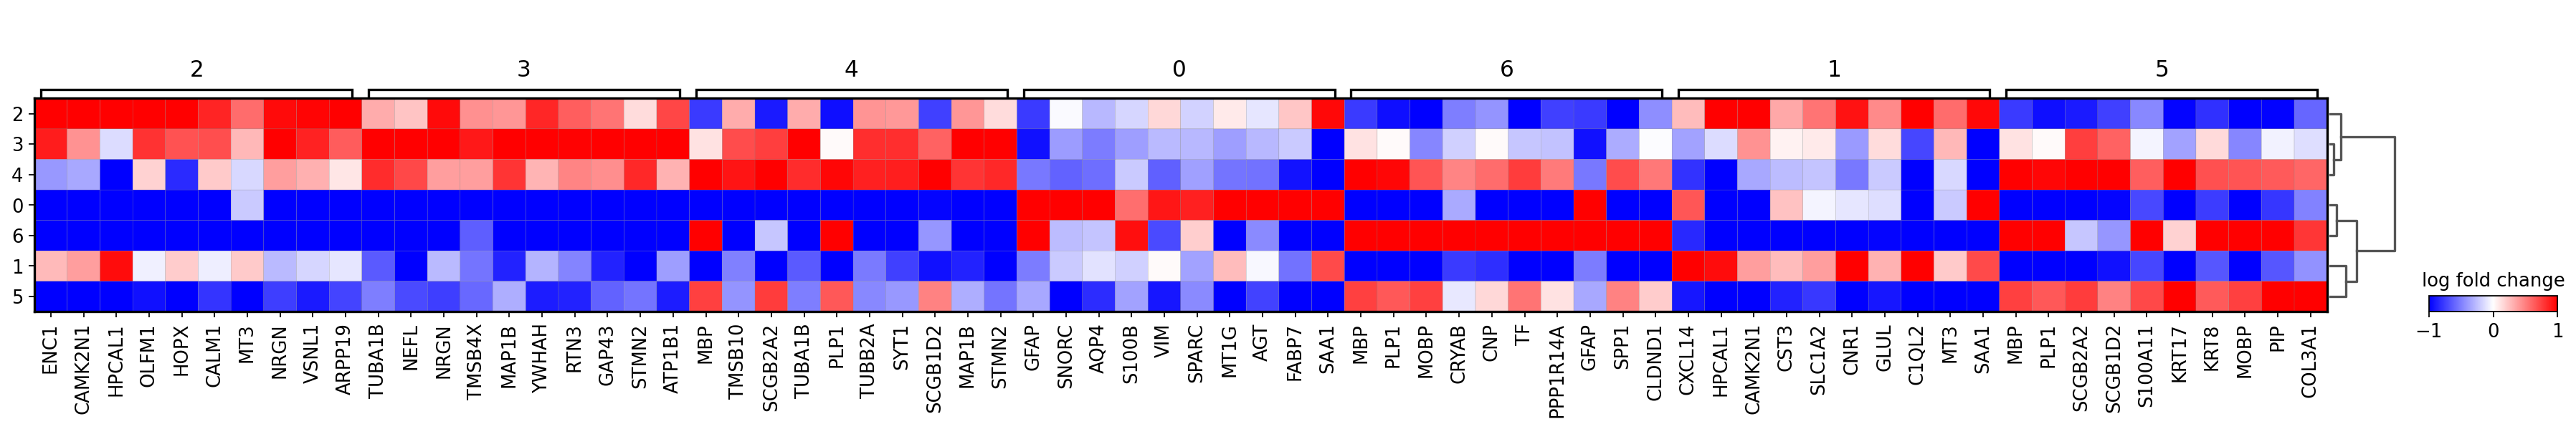

In [16]:
sc.pl.rank_genes_groups_matrixplot(adata, groupby='domain', use_raw=True, vmin=-1, vmax=1, cmap='bwr', values_to_plot='logfoldchanges')

In [9]:
results = adata.uns['rank_genes_groups']
groups = results['names'].dtype.names

figdir = f"./results/DLPFC/degenes/p1/"
if not os.path.exists(figdir):
    os.makedirs(figdir)
sc.settings.figdir = figdir

for group in groups:
    genes = results["names"][group][:5]
    print(f'Domain {group}, top {len(genes)} significant genes: {genes}')
    for i in range(151507, 151511):
        _adata = adata[adata.obs['batch'] == str(i)]
        for gene in genes:
            sc.pl.spatial(_adata, 
                          color=gene, 
                          library_id=str(i), 
                          img_key=None, 
                          size=1.3, 
                          cmap='Blues', 
                          show=False, 
                          save=f"_p1_{i}_{group}_{gene}.png"
                         )

Domain 0, top 5 significant genes: ['GFAP' 'SNORC' 'AQP4' 'S100B' 'VIM']
Domain 1, top 5 significant genes: ['CXCL14' 'HPCAL1' 'CAMK2N1' 'CST3' 'SLC1A2']
Domain 2, top 5 significant genes: ['ENC1' 'CAMK2N1' 'HPCAL1' 'OLFM1' 'HOPX']
Domain 3, top 5 significant genes: ['TUBA1B' 'NEFL' 'NRGN' 'TMSB4X' 'MAP1B']
Domain 4, top 5 significant genes: ['MBP' 'TMSB10' 'SCGB2A2' 'TUBA1B' 'PLP1']
Domain 5, top 5 significant genes: ['MBP' 'PLP1' 'SCGB2A2' 'SCGB1D2' 'S100A11']
Domain 6, top 5 significant genes: ['MBP' 'PLP1' 'MOBP' 'CRYAB' 'CNP']
